<a href="https://colab.research.google.com/github/marcheanin/hf_llm_course/blob/main/02_using_transformers/Using_HF_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Behind the pipline

Тут разберем что находится под абстракцией пайплайна.

Пайплайн совмещает в себе этапы: preprocessing, passing inpunts through the model, postprocessing:

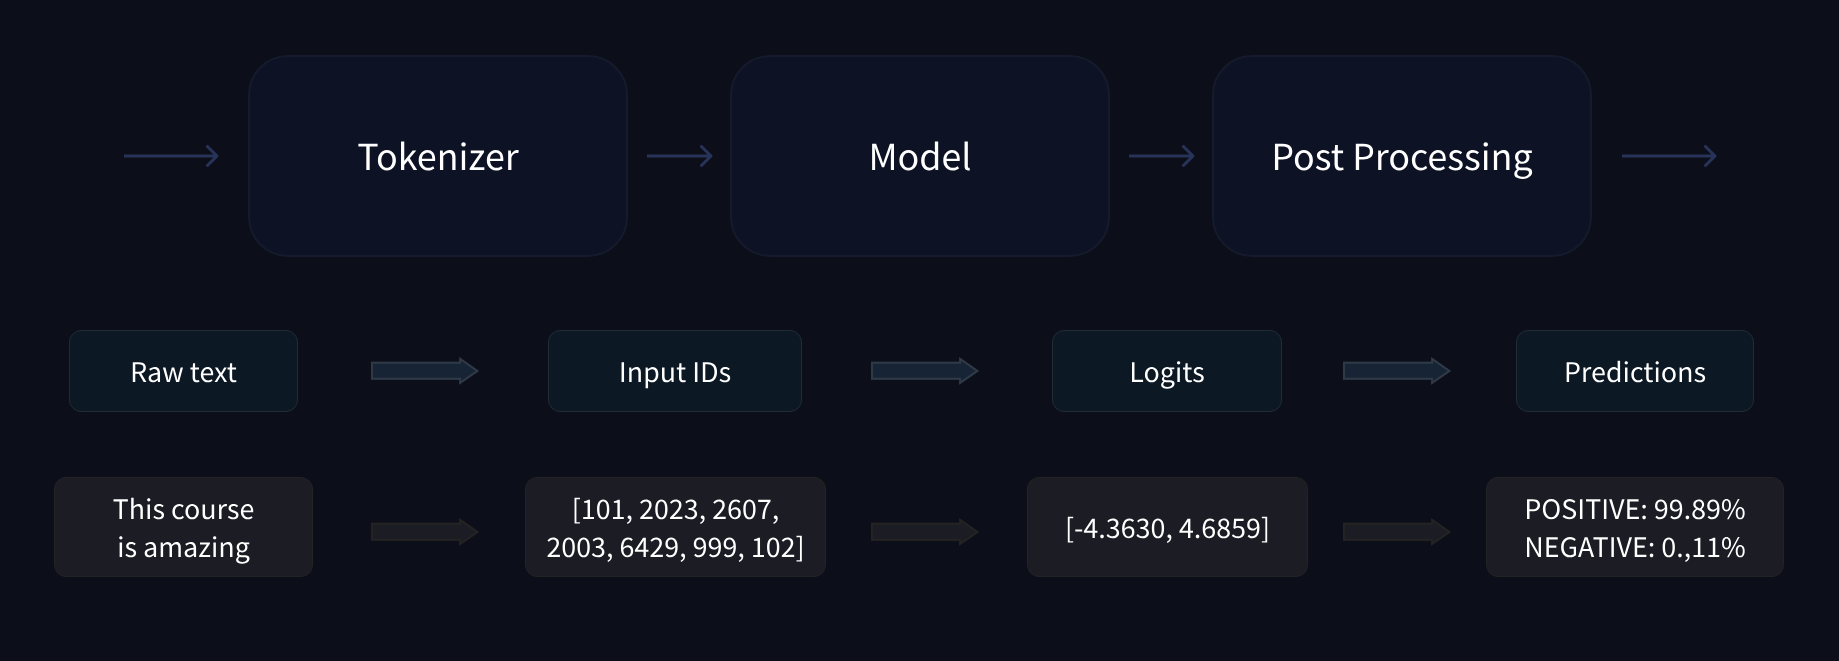

 Теперь пройдемся по всем этапам.

#### Пропроцессинг при помощи токенайзера

Трансформер не может принимать напрямую текст, поэтому его надо привести в численное представление. Токенизирование разбито на след этапы:

- Разбить текст на такие поднаборы символов, чтобы каждый набор был отдельным токеном
- Маппим токен к числу словарем
- Добавляем дополнительные токены, которые могут быть полезными для модели

Токенайзер скачивается вместе с моделью, так как неразрывно связан с ней.

In [1]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

На выходе токенайзера - словарь получившихся токенов, который можно напрямую передавать в модель. Токенайзеры имеют раный бэкенд в начинке, но все выдают на выходе тензоры.

Чтобы специфицировать выход токеназера, можно использовать сепециальный флан `return_tensors`

In [2]:
raw_inputs = [
    "I've been waiting for a HuggingFace course my whole life.",
    "I hate this so much!",
]
inputs = tokenizer(raw_inputs, padding=True, truncation=True, return_tensors="pt") # pt = pytorch tensors
print(inputs)

{'input_ids': tensor([[  101,  1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,
          2607,  2026,  2878,  2166,  1012,   102],
        [  101,  1045,  5223,  2023,  2061,  2172,   999,   102,     0,     0,
             0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])}


Получаем тензор из двух векторов, каждый из которых кодирует соответсвенное из двух предложений. Про attention_mask - позже

#### Дальше сквозь модель

Модель загружается из того же чекпоинта методом `AutoModel` методом `from_pretrained`


In [3]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModel.from_pretrained(checkpoint)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


В этом куске кода загрузили тот же чекпоинт, что и раньше, но вытащили уже модель. Текущая часть модели - базовый трансформер, на выходе получаем представляения/фичи/логиты

Вектор на выходе трансформера (вектор представления) содержит 3 разметрности:
- Batch Size - набор последовательностей, которые пропустили сквозь трансформер за один раз
- Sequence Length. Кол-во токенов в каждой переданной последовательности
- Hidden Size. Размерность вектора представления



In [4]:
outputs = model(**inputs)
print(outputs.last_hidden_state.shape)

torch.Size([2, 16, 768])


#### Головы модели

На прошлых этапах поличили высокоразмерные векторы, которые есть скрытые состояния на этой картинке

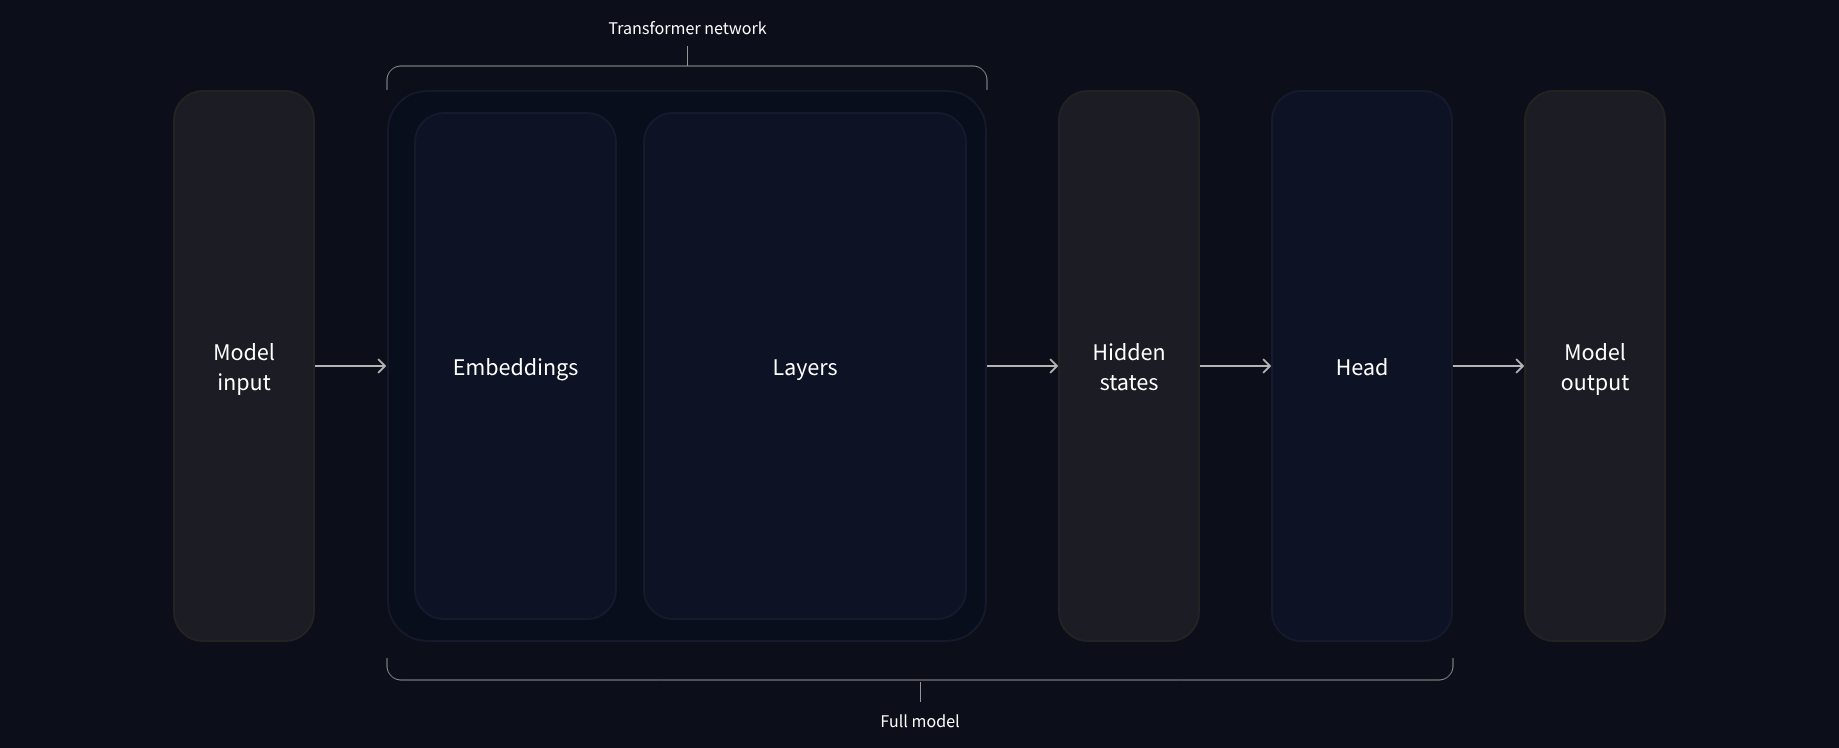

Embedding-слои на этой картинке транслируют то, что мы получили после токенайзера в векторы, затем они поступайют в слои самой модели.

Доопустим, мы хотим голову и модель для классификации.

In [5]:
from transformers import AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
outputs = model(**inputs)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [6]:
print(outputs.logits.shape)

torch.Size([2, 2])


Так как имели два предложения и две метки, получили размерность 2x2

#### Постпроцессим вывод

Выходы, полученные на предыдущем шаге, не несут часто особого смысла. Глянем:

In [7]:
print(outputs.logits)

tensor([[-1.5607,  1.6123],
        [ 4.1692, -3.3464]], grad_fn=<AddmmBackward0>)


Это не вероятности, это логиты. Чтобы перевести в вероятности, как водится, применим SoftMax.

In [8]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)

tensor([[4.0195e-02, 9.5980e-01],
        [9.9946e-01, 5.4418e-04]], grad_fn=<SoftmaxBackward0>)


Теперь ведим реальные предсказания для классов в вероятностях:

First sentence: NEGATIVE: 0.0402, POSITIVE: 0.9598\
Second sentence: NEGATIVE: 0.9995, POSITIVE: 0.0005

In [9]:
model.config.id2label

{0: 'NEGATIVE', 1: 'POSITIVE'}

По этим меткам и полученным вероятностям получаем финальные предсказания модели.

## Работа с моделями

Для загрузки модели используется класс `AutoModel`, который является общим для всех типов моделей.

In [10]:
from transformers import AutoModel

# Загружаем модель BERT с предобученными весами
model = AutoModel.from_pretrained("bert-base-cased")
# Если известна конкретная архитектура, можно использовать её класс напрямую
from transformers import BertModel
model = BertModel.from_pretrained("bert-base-cased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель можно сохранять себе. Получается файл конфига с архитектурой `config.json` и с весами модели `model.safetensors`

In [11]:
# Сохраняем модель в папку на компьютере
model.save_pretrained("directory_on_my_computer")

# Загружаем модель обратно с диска
model = AutoModel.from_pretrained("directory_on_my_computer")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Также можно закинуть модель на HF hub

In [ ]:
# Авторизация в Hugging Face (для ноутбука)
from huggingface_hub import notebook_login
notebook_login()
# Для терминала: huggingface-cli login

# Публикация модели
model.push_to_hub("my-awesome-model")
# Загрузка опубликованной модели
model = AutoModel.from_pretrained("your-username/my-awesome-model")

#### Токенезация - превращаем текст в числа

Сначала рассмотрим токенезацию одного предложения

In [12]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
encoded_input = tokenizer("Hello, I'm a single sentence!")
print(encoded_input)
# Обратное преобразование чисел в текст
print(tokenizer.decode(encoded_input["input_ids"]))

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': [101, 8667, 117, 146, 112, 182, 170, 1423, 5650, 106, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
[CLS] Hello, I ' m a single sentence! [SEP]


Токенезация пары предложений

In [13]:
encoded_input = tokenizer("How are you?", "I'm fine, thank you!")
print(encoded_input)

{'input_ids': [101, 1731, 1132, 1128, 136, 102, 146, 112, 182, 2503, 117, 6243, 1128, 106, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


Можем заставить вернуть PyTorch тензоры

In [14]:
encoded_input = tokenizer("How are you?", "I'm fine, thank you!", return_tensors="pt")
print(encoded_input)

{'input_ids': tensor([[ 101, 1731, 1132, 1128,  136,  102,  146,  112,  182, 2503,  117, 6243,
         1128,  106,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


#### Паддинг и обрезка

Паддинг - выравнивает все предложения в батче до одной длины, добавляя специальные токены (0)

In [15]:
encoded_input = tokenizer(
    ["How are you?", "I'm fine, thank you!"],
    padding=True,
    return_tensors="pt"
)
print(encoded_input)
# Обратите внимание на нули в input_ids и attention_mask для первого предложения

{'input_ids': tensor([[ 101, 1731, 1132, 1128,  136,  102,    0,    0,    0,    0],
        [ 101,  146,  112,  182, 2503,  117, 6243, 1128,  106,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Обрезка - укорачивает длинные последовательности до максимальной длины, которую может обработать модель (например, 512 для BERT)

In [16]:
long_text = "This is a very very ... long sentence." # Очень длинный текст
encoded_input = tokenizer(long_text, truncation=True)
print(len(encoded_input["input_ids"]))

13


Можем комбинировать паддинг и обрезку для создания батчей одинакового, управляемого размера

In [17]:
encoded_input = tokenizer(
    ["How are you?", "I'm fine, thank you!"],
    padding=True,
    truncation=True,
    max_length=5,
    return_tensors="pt",
)
print(encoded_input)

{'input_ids': tensor([[ 101, 1731, 1132, 1128,  102],
        [ 101,  146,  112,  182,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]])}


#### Подача данных в модель

Токенезированные данные уже передаем в модель для получения результата. Там они проходят этап эмбеддера и остальные слои

In [18]:
import torch

# Пример списка закодированных последовательностей
encoded_sequences = [
    [101, 1045, 1005, 2310, 2042, 3403, 2005, 1037, 17662, 12172, 2607, 2026, 2878, 2166, 1012, 102],
    [101, 1045, 5223, 2023, 2061, 2172, 999, 102, 0, 0, 0, 0, 0, 0, 0, 0]
]

# Превращаем список в тензор PyTorch
model_inputs = torch.tensor(encoded_sequences)

# Передаем тензор в модель
output = model(model_inputs)

## Токенизаторы

Рассмотрим в этом разделе подробнее какие они бывают, как из загружать и применять.

Нейросеть работает с числами, поэтому задача токенайзера - найти эффективные способы переноса текста в числа. Одна из основных проблем - обработка незнакомых слов. Вся эволюция токеназеров направлена на решение этой проблемы.

## Word-Based

Принцип: делим по пробелам и знакам припинания. Каждому элементу свой ID и соответственно токен.

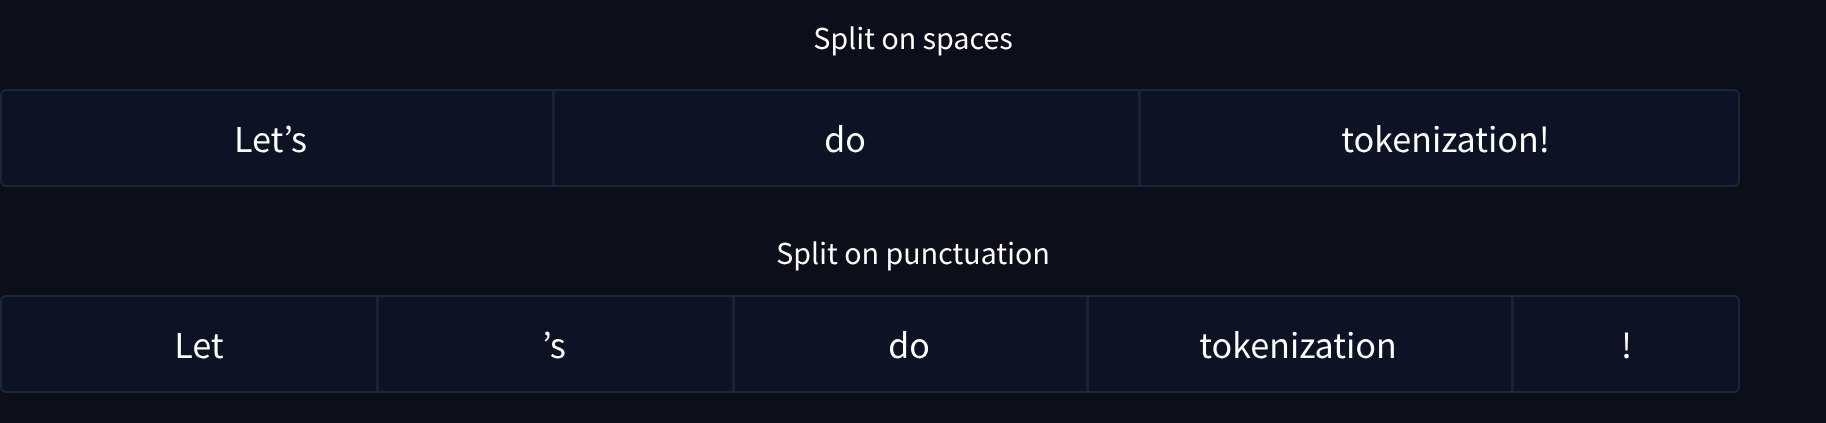

Есть ряд проблем, с которыми встречается такой подход:

1. Огромный словарь. В английском языке 500.000 слов, хранить все - ресурснозатратно.
2. Для любого слова вне слова заменяем токен на `[UNK]`, информация теряется
3. Модель не связи между токенами "dog" и "dogs" и тп - для нее это всё разные, никак не связанные индексы.

## Побуквенный токенайзер

Разбиваем слова посимвольно. Каждому уникальному символу - свой ID.
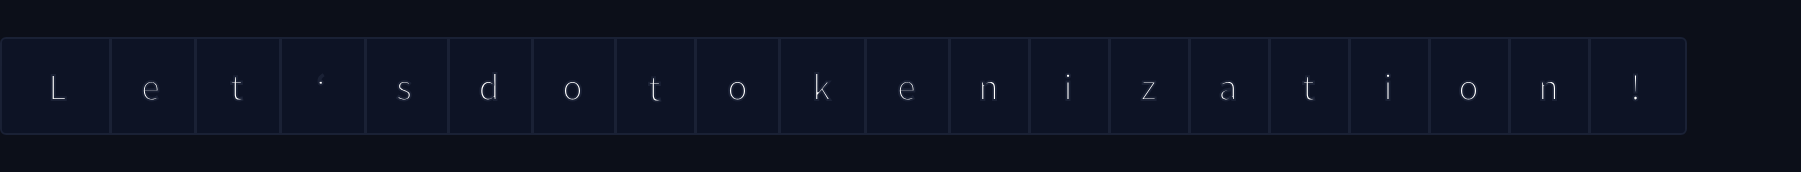

**Плюсы:**
*   Очень маленький словарь.
*   Практически нет токенов `[UNK]` (любое слово можно составить из символов).

**Минусы:**
*   **Потеря смысла:** Отдельный символ (особенно в латинице) несет мало информации по сравнению со словом.
*   **Длинные последовательности:** Слово из 5 символов превращается в 5 токенов. Модели сложнее обрабатывать длинные последовательности и искать зависимости между символами.


## Subword Torenizer

Не разбиваем часто используемые слова. Редкие слова разбиваются на известные составляющие. Слово "annoyingly" (редкое) -> "annoying" (частое) + "ly" (частое). Смысл сохраняется, словарь компактный, `[UNK]` почти исчезают.

Это идеально для языков с богатой морфологией, где можно склеивать части слов в бесконечно длинные конструкции.
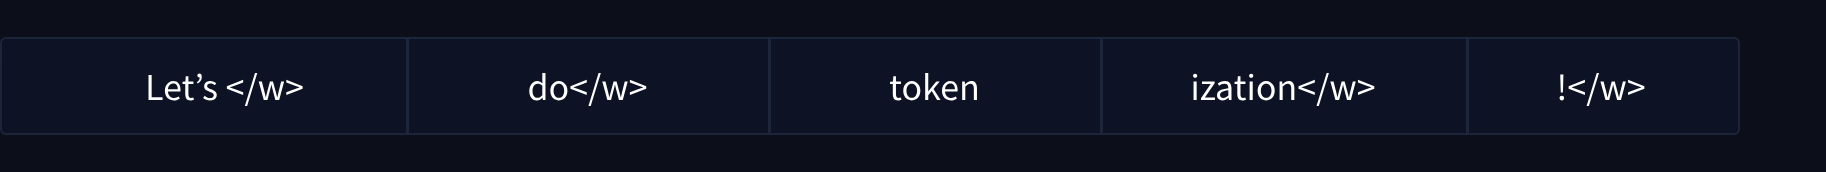

Существует много технологий токенайзинга, например, популярная BPE, которая бъет не слова, а последовательности байтов, однако и она использует subword-механизм разбиения на часто всречающиеся токены.

#### Загрузка и сохранение

Процесс загрузки и сохранения токенайзеров такой же простой, как и с моделями. Используем те же функции `frpm_pretraided()` и `save_pretrained()`

In [19]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

Аналогично AutoModel, можно использовать AutoTokemizer

In [20]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

Покажем пример использования токенайзера

In [21]:
tokenizer("Using a Transformer network is simple")

{'input_ids': [101, 7993, 170, 13809, 23763, 2443, 1110, 3014, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

#### Encoding

Состоит из двух этапов - разбиение на токены и преобразование их в числа соотв. их айдишникам.

Рассмотрим эти этапы в коде

In [22]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
tokens = tokenizer.tokenize("Using a Transformer network is simple")
print(tokens)

['Using', 'a', 'Trans', '##former', 'network', 'is', 'simple']


In [23]:
# Обратите внимание на 'transform' и '##er' — это и есть результат работы
# субсловного алгоритма WordPiece. '##' означает, что токен является частью
# предыдущего слова.

Теперь переведем токены в числа. В реальной работе токенайзера оба этапа неразрывны.

In [24]:
input_ids = tokenizer.convert_tokens_to_ids(tokens)
print(input_ids)

[7993, 170, 13809, 23763, 2443, 1110, 3014]


После того, как модель выбраала результатом набор токенов, их надо обратно собрать в текст. Это делает метод `decode()`, при этом он собирает слова обратно воедино

In [25]:
decoded_string = tokenizer.decode([7993, 170, 11303, 1200, 2443, 1110, 3014])
print(decoded_string)

Using a transformer network is simple


## Обработка нескольких последовательностей

Тут посмотрим как работать с набором предложений, как приводить их к одной длине, как бороться со слишком длинными предложениями.

#### Модели ожидают на вход батчи

Если мы попробуем дать численный выход токенайзера модели в виде тензоров, получим ошибку, так как даже для одной последовательности нужная еще одна размерность.



In [26]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence = "I've been waiting for a HuggingFace course my whole life."

tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)
input_ids = torch.tensor(ids)
# This line will fail.
model(input_ids)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

RuntimeError: The size of tensor a (14) must match the size of tensor b (512) at non-singleton dimension 1

In [27]:
tokenized_inputs = tokenizer(sequence, return_tensors="pt")
print(tokenized_inputs["input_ids"])

tensor([[  101,  1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,
          2607,  2026,  2878,  2166,  1012,   102]])


Теперь напишем всё сразу корректно, добавив новое измерение:

In [28]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence = "I've been waiting for a HuggingFace course my whole life."

tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)

input_ids = torch.tensor([ids]) # вот тут новое измерение
print("Input IDs:", input_ids)

output = model(input_ids)
print("Logits:", output.logits)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Input IDs: tensor([[ 1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,  2607,
          2026,  2878,  2166,  1012]])
Logits: tensor([[-2.7276,  2.8789]], grad_fn=<AddmmBackward0>)


И вот можно прогнать сразу два одинаковых предложения, получив одни и те же логиты:

In [29]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence = "I've been waiting for a HuggingFace course my whole life."

tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)

input_ids = torch.tensor([ids, ids]) # вот тут новое измерение
print("Input IDs:", input_ids)

output = model(input_ids)
print("Logits:", output.logits)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Input IDs: tensor([[ 1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,  2607,
          2026,  2878,  2166,  1012],
        [ 1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,  2607,
          2026,  2878,  2166,  1012]])
Logits: tensor([[-2.7276,  2.8789],
        [-2.7276,  2.8789]], grad_fn=<AddmmBackward0>)


#### Padding

Вот такой список списков нельзя сконвертировать в тензор:

In [ ]:
batched_ids = [
    [200, 200, 200],
    [200, 200]
]

Всё потому что он не прямоугольной формы. Паддинг нужен именно для того, чтобы список списков стал прямоугольным - это актульно для предложений разного размера. Вот так можно провести паддинг:

In [30]:
padding_id = 100

batched_ids = [
    [200, 200, 200],
    [200, 200, padding_id],
]

Можно получить паддинговый токен напрямую из токенайзера

In [31]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence1_ids = [[200, 200, 200]]
sequence2_ids = [[200, 200]]
batched_ids = [
    [200, 200, 200],
    [200, 200, tokenizer.pad_token_id],
]

print(model(torch.tensor(sequence1_ids)).logits)
print(model(torch.tensor(sequence2_ids)).logits)
print(model(torch.tensor(batched_ids)).logits)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tensor([[ 1.5694, -1.3895]], grad_fn=<AddmmBackward0>)
tensor([[ 0.5803, -0.4125]], grad_fn=<AddmmBackward0>)
tensor([[ 1.5694, -1.3895],
        [ 1.3374, -1.2163]], grad_fn=<AddmmBackward0>)


При этом получаем странность - не равные логиты. Это происходит потому, что внимание трансформера восприняла и паддинг токены тоже. Чтобы это не проиходило, нужно установить метод игнорирования паддинг токенов. Это делается с помощью `attention masks`

#### Attention Masks

Это тензор точно такого же размера, как и входное предложение. Он обозначает, какие токены надо брать во внимание, а какие - нет. Состоят из 0 и 1. Вот как мы решим предыдущую проблему с паддингами с помощью маски

In [32]:
batched_ids = [
    [200, 200, 200],
    [200, 200, tokenizer.pad_token_id],
]

attention_mask = [
    [1, 1, 1],
    [1, 1, 0],
]

outputs = model(torch.tensor(batched_ids), attention_mask=torch.tensor(attention_mask))
print(outputs.logits)

tensor([[ 1.5694, -1.3895],
        [ 0.5803, -0.4125]], grad_fn=<AddmmBackward0>)


Также, нужно следить за тем, чтобы транформер был способен принимать последовательности переданной длины. Иначе, их проще всего просто обрезать, или выбрать другую модель с более длинным контекстом

`sequence = sequence[:max_sequence_length]`

## Объединение всего вместе

Рассмотим тут как совмещаются и абстрагируются методы, рассмотренные выше.

Токейнайзер берет например всю предобработку на себя и мы можем подготовить входы модели так:

In [33]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

sequence = "I've been waiting for a HuggingFace course my whole life."

model_inputs = tokenizer(sequence)

Может также работать с несколькими последовательностями

In [35]:
sequences = ["I've been waiting for a HuggingFace course my whole life.", "So have I!"]

model_inputs = tokenizer(sequences)

Можно также автоматически применить паддинг

In [36]:
# Паддит по максимальной длине из всех переданных
model_inputs = tokenizer(sequences, padding="longest")

# Паддит до максимальной входной длины
model_inputs = tokenizer(sequences, padding="max_length")

# Также можем сами передать длину до которой паддить
model_inputs = tokenizer(sequences, padding="max_length", max_length=8)

Также, доступно обрезание слишком длинной последовательности

In [37]:
# Will pad the sequences up to the maximum sequence length
model_inputs = tokenizer(sequences, padding="longest")

# Will pad the sequences up to the model max length
# (512 for BERT or DistilBERT)
model_inputs = tokenizer(sequences, padding="max_length")

# Will pad the sequences up to the specified max length
model_inputs = tokenizer(sequences, padding="max_length", max_length=8)

Токенайзеры могут возвращать тензоры или np массивы в зависимости от настройки

In [38]:
sequences = ["I've been waiting for a HuggingFace course my whole life.", "So have I!"]

# Returns PyTorch tensors
model_inputs = tokenizer(sequences, padding=True, return_tensors="pt")

# Returns NumPy arrays
model_inputs = tokenizer(sequences, padding=True, return_tensors="np")

#### Специальные токены

Такие токены как [CLS] [SEP] и т д также храняться в словаре токенайзера и добавляются при нелбходимости

In [39]:
sequence = "I've been waiting for a HuggingFace course my whole life."

model_inputs = tokenizer(sequence)
print(model_inputs["input_ids"])

tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)
print(ids)

[101, 1045, 1005, 2310, 2042, 3403, 2005, 1037, 17662, 12172, 2607, 2026, 2878, 2166, 1012, 102]
[1045, 1005, 2310, 2042, 3403, 2005, 1037, 17662, 12172, 2607, 2026, 2878, 2166, 1012]


In [40]:
print(tokenizer.decode(model_inputs["input_ids"]))
print(tokenizer.decode(ids))

[CLS] i ' ve been waiting for a huggingface course my whole life. [SEP]
i ' ve been waiting for a huggingface course my whole life.


#### Из токенайзера в модель

Теперь когда мы знаем всёё про токенайзеры, можем передать их вывод в модель

In [41]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
sequences = ["I've been waiting for a HuggingFace course my whole life.", "So have I!"]

tokens = tokenizer(sequences, padding=True, truncation=True, return_tensors="pt")
output = model(**tokens)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [42]:
output

SequenceClassifierOutput(loss=None, logits=tensor([[-1.5607,  1.6123],
        [-3.6183,  3.9137]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)